In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
def process_data(df, indicator_name):

    # Remove metadata safely
    df = df.drop(columns=["Indicator Name", "Indicator Code"], errors="ignore")

    # Keep Country Code for filtering
    if "Country Code" in df.columns:
        df = df[df["Country Code"].str.len() == 3]

    # Keep only year columns
    df = df.loc[:, df.columns.str.match(r'^\d{4}$') | 
                     (df.columns.isin(["Country Name", "Country Code"]))]

    # Wide → long
    df = df.melt(id_vars=["Country Name", "Country Code"], 
                 var_name="Year", 
                 value_name=indicator_name)

    # Clean year
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"])
    df["Year"] = df["Year"].astype(int)

    # Filter time window
    df = df[(df["Year"] >= 1995) & (df["Year"] <= 2023)]

    # Drop missing values
    df = df.dropna(subset=[indicator_name])

    # Rename
    df = df.rename(columns={"Country Name": "Country"})

    return df

In [83]:
gdp = pd.read_csv(r"C:\Users\slalu\Downloads\economic_fragility_project\GDP.csv", skiprows=4)
gdp_long = process_data(gdp, "gdp")
inflation = pd.read_csv(r"C:\Users\slalu\Downloads\economic_fragility_project\Inflation.csv", skiprows=4)
inflation_long = process_data(inflation, "inflation")
unemployment = pd.read_csv(r"C:\Users\slalu\Downloads\economic_fragility_project\UEM.csv",skiprows=4)
unemployment_long = process_data(unemployment, "unemployment")
debt = pd.read_csv(r"C:\Users\slalu\Downloads\economic_fragility_project\Debt.csv", skiprows=4)
debt_long = process_data(debt, "debt")
current = pd.read_csv(r"C:\Users\slalu\Downloads\economic_fragility_project\Current_account.csv", skiprows=4)
current_long = process_data(current, "current")
reserves = pd.read_csv(r"C:\Users\slalu\Downloads\economic_fragility_project\Reserves.csv", skiprows=4)
reserves_long = process_data(reserves, "reserves")
interest = pd.read_csv(r"C:\Users\slalu\Downloads\economic_fragility_project\Interest.csv", skiprows=4)
interest_long = process_data(interest, "interest")
exchange = pd.read_csv(r"C:\Users\slalu\Downloads\economic_fragility_project\ExchangeRate.csv", skiprows=4)
exchange_long = process_data(exchange, "exchange")
trade = pd.read_csv(r"C:\Users\slalu\Downloads\economic_fragility_project\TradeGDP.csv", skiprows=4)
trade_long = process_data(trade, "trade")

In [85]:
master = gdp_long \
    .merge(inflation_long, on=["Country","Country Code","Year"], how="outer") \
    .merge(unemployment_long, on=["Country","Country Code","Year"], how="outer") \
    .merge(debt_long, on=["Country","Country Code","Year"], how="outer") \
    .merge(current_long, on=["Country","Country Code","Year"], how="outer") \
    .merge(reserves_long, on=["Country","Country Code","Year"], how="outer") \
    .merge(interest_long, on=["Country","Country Code","Year"], how="outer") \
    .merge(exchange_long, on=["Country","Country Code","Year"], how="outer") \
    .merge(trade_long, on=["Country","Country Code","Year"], how="outer")

In [87]:
missing_summary = master.isna().mean().sort_values(ascending=False) * 100
print(missing_summary)

debt            80.916830
interest        54.106090
current         34.865750
reserves        34.315652
exchange        21.637197
trade           18.650950
inflation       14.590701
unemployment    10.792403
gdp              2.606418
Year             0.000000
Country          0.000000
Country Code     0.000000
dtype: float64


In [89]:
country_missing = master.groupby("Country").apply(lambda x: x.isna().mean().mean(),include_groups=False)
country_missing.sort_values(ascending=False).head(20)

Country
Korea, Dem. People's Rep.                   0.727273
Gibraltar                                   0.727273
St. Martin (French part)                    0.714734
Andorra                                     0.702194
Tuvalu                                      0.655172
Turks and Caicos Islands                    0.639498
Isle of Man                                 0.639498
Monaco                                      0.636364
Liechtenstein                               0.636364
Northern Mariana Islands                    0.595611
American Samoa                              0.595611
Cayman Islands                              0.592476
Greenland                                   0.570533
Somalia, Fed. Rep.                          0.564263
Pacific island small states                 0.561129
Channel Islands                             0.557994
Cuba                                        0.554859
Sint Maarten (Dutch part)                   0.550505
Fragile and conflict affected situatio

In [91]:
# Remove aggregates & non-sovereign entities
remove_keywords = [
    "income", "IDA", "IBRD", "states", "situations",
    "Arab World", "Pacific island", "small states"
]

for word in remove_keywords:
    master = master[~master["Country"].str.contains(word, case=False, na=False)]

In [93]:
country_missing = master.groupby("Country").apply(lambda x: x.isna().mean().mean(),include_groups=False)

valid_countries = country_missing[country_missing < 0.40].index

master = master[master["Country"].isin(valid_countries)]

In [95]:
master.groupby("Year")["debt"].apply(lambda x: x.isna().mean())
print(master.head(10))
print(master.tail(20))

       Country Country Code  Year           gdp  inflation  unemployment  \
0  Afghanistan          AFG  1995           NaN        NaN         7.868   
1  Afghanistan          AFG  1996           NaN        NaN         7.878   
2  Afghanistan          AFG  1997           NaN        NaN         7.863   
3  Afghanistan          AFG  1998           NaN        NaN         7.869   
4  Afghanistan          AFG  1999           NaN        NaN         7.877   
5  Afghanistan          AFG  2000  3.521418e+09        NaN         7.897   
6  Afghanistan          AFG  2001  2.813572e+09        NaN         7.973   
7  Afghanistan          AFG  2002  3.825701e+09        NaN         7.867   
8  Afghanistan          AFG  2003  4.520947e+09        NaN         7.844   
9  Afghanistan          AFG  2004  5.224897e+09        NaN         7.794   

   debt  current  reserves  interest   exchange  trade  
0   NaN      NaN       NaN       NaN  36.567145    NaN  
1   NaN      NaN       NaN       NaN  47.500000  

In [97]:
master = master[(master["Year"] >= 2005) & (master["Year"] <= 2023)]

missing = master.isna().mean().sort_values(ascending=False)*100
print(missing)

country_missing = master.groupby("Country").apply(lambda x: x.isna().mean().mean(),include_groups=False)
print(country_missing.sort_values(ascending=False).head(15))

debt            74.646293
interest        33.078664
trade           11.375212
reserves         8.234295
current          7.923033
unemployment     4.951896
inflation        2.999434
exchange         2.631579
gdp              0.254669
Year             0.000000
Country          0.000000
Country Code     0.000000
dtype: float64
Country
South Asia                  0.387560
New Caledonia               0.368421
North America               0.363636
Syrian Arab Republic        0.339713
Iran, Islamic Rep.          0.306220
United Arab Emirates        0.277512
Dominica                    0.272727
Equatorial Guinea           0.272727
Chad                        0.272727
Central African Republic    0.272727
Euro area                   0.272727
Grenada                     0.272727
Yemen, Rep.                 0.267943
Afghanistan                 0.267943
Venezuela, RB               0.263158
dtype: float64


In [99]:
master = master.drop(columns=["debt"])

In [101]:
remove_words = ["South Asia", "North America", "Euro area"]

for word in remove_words:
    master = master[~master["Country"].str.contains(word, case=False, na=False)]

In [103]:
master = master.sort_values(["Country", "Year"])

master["gdp_growth"] = master.groupby("Country")["gdp"].pct_change() * 100

C:\Users\slalu\AppData\Local\Temp\ipykernel_19312\3527599643.py:3: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  master["gdp_growth"] = master.groupby("Country")["gdp"].pct_change() * 100


In [105]:
master = master.dropna(subset=["gdp_growth"])

In [107]:
master["exchange_depr"] = master.groupby("Country")["exchange"].pct_change() * 100

C:\Users\slalu\AppData\Local\Temp\ipykernel_19312\2023070002.py:1: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  master["exchange_depr"] = master.groupby("Country")["exchange"].pct_change() * 100


In [109]:
master["reserves_gdp"] = (master["reserves"] / master["gdp"]) * 100

In [111]:
master["real_interest"] = master["interest"] - master["inflation"]

In [113]:
master.drop(columns=["gdp","exchange","reserves"],inplace = True)

In [115]:
master.describe()

,Year,inflation,unemployment,current,interest,trade,gdp_growth,exchange_depr,reserves_gdp,real_interest
count,3291.000000,3195.000000,3128.000000,3087.000000,2231.000000,2916.000000,3291.000000,3.084000e+03,3049.000000,2192.000000
mean,2014.506837,6.296414,7.837816,-2.338571,11.940445,90.518627,6.608797,2.251494e+04,21.413606,5.535452
std,5.186275,16.805342,6.007586,15.160956,9.182445,56.909355,13.724840,1.249768e+06,22.022813,15.969696
min,2006.000000,-16.859691,0.100000,-59.995551,0.500000,2.473729,-54.057274,-1.000000e+02,0.062829,-524.193484
25%,2010.000000,1.613008,3.665500,-7.645691,6.463254,55.026136,-0.165148,-1.762214e+00,9.037571,2.653058
50%,2015.000000,3.608024,5.921000,-2.852826,10.015000,77.484986,6.240122,1.784839e-01,15.963093,5.087066
75%,2019.000000,7.106194,10.348000,1.745505,14.835000,107.654300,12.987100,5.492999e+00,25.990554,8.844171
max,2023.000000,557.201817,36.472000,311.746071,170.293833,442.620019,188.504559,6.940437e+07,233.579661,62.617500


In [117]:
def winsorize_series(s):
    lower = s.quantile(0.01)
    upper = s.quantile(0.99)
    return s.clip(lower, upper)

cols = [
    "inflation", "current", "trade",
    "gdp_growth", "exchange_depr",
    "reserves_gdp", "real_interest"
]

for col in cols:
    master[col] = winsorize_series(master[col])

In [119]:
# Percentile thresholds
gdp_thresh = master["gdp_growth"].quantile(0.15)
infl_thresh = master["inflation"].quantile(0.85)
exch_thresh = master["exchange_depr"].quantile(0.85)
current_thresh = master["current"].quantile(0.15)
reserves_thresh = master["reserves_gdp"].quantile(0.15)

# Conditions
conditions = (
    (master["gdp_growth"] <= gdp_thresh).astype(int) +
    (master["inflation"] >= infl_thresh).astype(int) +
    (master["exchange_depr"] >= exch_thresh).astype(int) +
    (master["current"] <= current_thresh).astype(int) +
    (master["reserves_gdp"] <= reserves_thresh).astype(int)
)

master["crisis"] = (conditions >= 2).astype(int)

In [121]:
master["crisis"].value_counts(normalize=True)

crisis
0    0.823762
1    0.176238
Name: proportion, dtype: float64

In [123]:
master["crisis"].value_counts()

crisis
0    2711
1     580
Name: count, dtype: int64

In [125]:
master = master.dropna()

In [127]:
master.isnull().sum()

Country          0
Country Code     0
Year             0
inflation        0
unemployment     0
current          0
interest         0
trade            0
gdp_growth       0
exchange_depr    0
reserves_gdp     0
real_interest    0
crisis           0
dtype: int64

In [129]:
master["Country"].nunique()

109

In [131]:
# Print crisis rate for reporting
crisis_rate = master["crisis"].mean() * 100
print(f"Crisis observations: {master['crisis'].sum()}")
print(f"Non-crisis observations: {(master['crisis']==0).sum()}")
print(f"Crisis rate: {crisis_rate:.2f}%")

Crisis observations: 260
Non-crisis observations: 1273
Crisis rate: 16.96%


In [133]:
train = master[master["Year"] <= 2018]
test = master[master["Year"] > 2018]

X_train = train.drop(columns=["Country", "Country Code", "Year", "crisis"])
y_train = train["crisis"]

X_test = test.drop(columns=["Country", "Country Code", "Year", "crisis"])
y_test = test["crisis"]

In [135]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [137]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, classification_report, confusion_matrix
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_lr = grid.best_estimator_
y_pred = best_lr.predict(X_test_scaled)
y_prob = best_lr.predict_proba(X_test_scaled)[:,1]
lr_acc = accuracy_score(y_test, y_pred)
print("Accuracy:",lr_acc)
lr_auc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", lr_auc)

Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Score: 0.9398930753128661
Accuracy: 0.9230769230769231
ROC AUC: 0.9669802703690171


In [139]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}
rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print("Best RF Params:", rf_grid.best_params_)
rf_pred = best_rf.predict(X_test)
rf_prob = best_rf.predict_proba(X_test)[:,1]
rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)
print("RF Accuracy:", rf_acc)
print("RF AUC:", rf_auc)

Best RF Params: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
RF Accuracy: 0.9871794871794872
RF AUC: 0.9944282060650347


In [145]:
feat_imp = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top 5 RF Features:\n", feat_imp)

Top 5 RF Features:
 exchange_depr    0.406575
gdp_growth       0.245891
inflation        0.113566
current          0.079787
reserves_gdp     0.056239
interest         0.032265
real_interest    0.030813
trade            0.018282
unemployment     0.016582
dtype: float64


In [147]:
from xgboost import XGBClassifier
xgb_params = {"n_estimators": [100,200], "max_depth": [3,5,7], "learning_rate": [0.01,0.1], "subsample": [0.8,1]}
xgb_grid = GridSearchCV(XGBClassifier(eval_metric="logloss", random_state=42), xgb_params, cv=5, scoring="roc_auc", n_jobs=-1)
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = best_xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)
print(f"XGBoost - Accuracy: {xgb_acc:.4f}, AUC: {xgb_auc:.4f}")
print("Best XGB Params:", xgb_grid.best_params_)

XGBoost - Accuracy: 0.9897, AUC: 0.9978
Best XGB Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


In [149]:
results = {
"Logistic Regression":[lr_acc, lr_auc],
"Random Forest":[rf_acc,rf_auc],
"XGBoost":[xgb_acc,xgb_auc]
}
results_df = pd.DataFrame(results,index=["Accuracy","ROC_AUC"]).T
print(results_df)

                     Accuracy   ROC_AUC
Logistic Regression  0.923077  0.966980
Random Forest        0.987179  0.994428
XGBoost              0.989744  0.997762


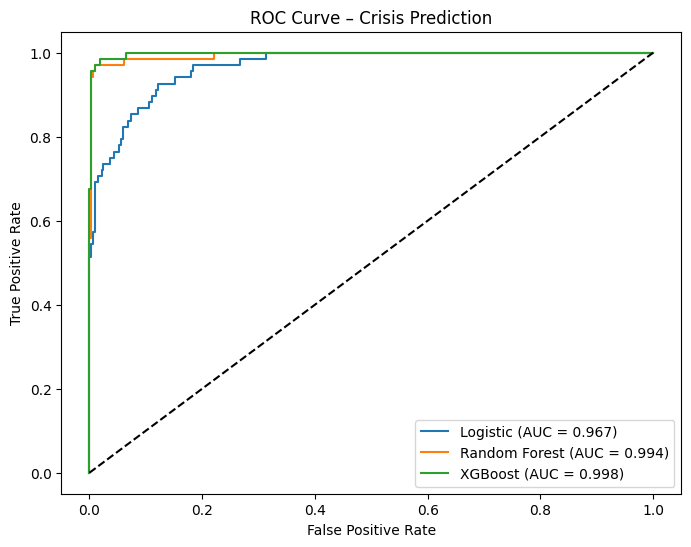

In [153]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# After Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob)
# After Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
# After XGBoost
fpr_xg, tpr_xg, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label="Logistic (AUC = %.3f)" % lr_auc)
plt.plot(fpr_rf, tpr_rf, label="Random Forest (AUC = %.3f)" % rf_auc)
plt.plot(fpr_xg, tpr_xg, label="XGBoost (AUC = %.3f)" % xgb_auc)
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Crisis Prediction")
plt.legend()
plt.show()

In [200]:
master = master.sort_values(["Country", "Year"])

# ========== CREATE T+1 TARGET ==========
master["crisis_next_year"] = master.groupby("Country")["crisis"].shift(-1)
master_early = master.dropna(subset=["crisis_next_year"])

Logistic Regression (t+1) - Accuracy: 0.8346, AUC: 0.7293
Best LR Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Random Forest (t+1) - Accuracy: 0.8372, AUC: 0.6876
Best RF Params: {'criterion': 'entropy', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2}

Top 5 RF Features (t+1):
 exchange_depr          0.084105
exchange_volatility    0.078818
gdp_growth_lag1        0.066088
inflation              0.062139
current                0.062136
dtype: float64
XGBoost (t+1) - Accuracy: 0.8424, AUC: 0.7190
Best XGB Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

===== PHASE 1 EARLY WARNING (t+1) RESULTS =====
                     Accuracy   ROC_AUC
Logistic Regression  0.834625  0.729350
Random Forest        0.837209  0.687577
XGBoost              0.842377  0.719013


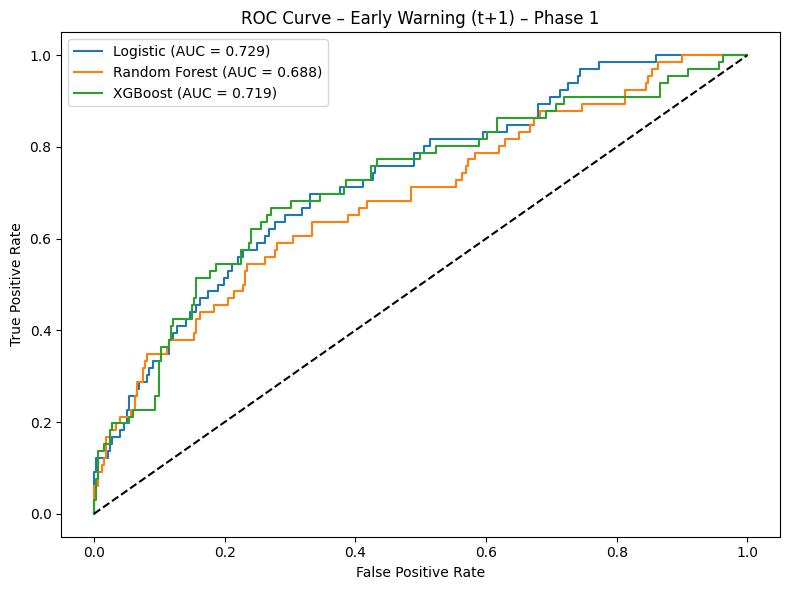


Classification Report - XGBoost (t+1):
              precision    recall  f1-score   support

         0.0       0.85      0.99      0.91       321
         1.0       0.69      0.14      0.23        66

    accuracy                           0.84       387
   macro avg       0.77      0.56      0.57       387
weighted avg       0.82      0.84      0.80       387



In [209]:
# Train: up to 2017 (to predict 2018 as t+1)
# Test: 2018-2023 (but t+1 target for 2018 uses 2018 features? Wait carefully)
# Actually: If Year = 2017, crisis_next_year = crisis(2018). So we train on Year ≤ 2017.
train_early = master_early[master_early["Year"] <= 2017]
test_early = master_early[master_early["Year"] > 2017]   # Years 2018-2023

X_train_e = train_early.drop(columns=["Country", "Country Code", "Year", "crisis", "crisis_next_year"])
y_train_e = train_early["crisis_next_year"]
X_test_e = test_early.drop(columns=["Country", "Country Code", "Year", "crisis", "crisis_next_year"])
y_test_e = test_early["crisis_next_year"]

# ========== SCALING FOR LOGISTIC REGRESSION ==========
scaler_e = StandardScaler()
X_train_e_scaled = scaler_e.fit_transform(X_train_e)
X_test_e_scaled = scaler_e.transform(X_test_e)
master_early = master_early.dropna()

# ========== LOGISTIC REGRESSION (t+1) ==========
lr_params = {"C": [0.01, 0.1, 1, 10, 100], "penalty": ["l1", "l2"], "solver": ["liblinear"]}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), lr_params, cv=5, scoring="roc_auc", n_jobs=-1)
lr_grid.fit(X_train_e_scaled, y_train_e)
best_lr_e = lr_grid.best_estimator_
y_prob_lr_e = best_lr_e.predict_proba(X_test_e_scaled)[:, 1]
y_pred_lr_e = best_lr_e.predict(X_test_e_scaled)
lr_acc_e = accuracy_score(y_test_e, y_pred_lr_e)
lr_auc_e = roc_auc_score(y_test_e, y_prob_lr_e)
print(f"Logistic Regression (t+1) - Accuracy: {lr_acc_e:.4f}, AUC: {lr_auc_e:.4f}")
print("Best LR Params:", lr_grid.best_params_)

# ========== RANDOM FOREST (t+1) ==========
rf_params = {
    'max_depth': [7, 10, 15],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}
rf_grid = GridSearchCV(
    RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring="roc_auc",   # FIXED: use roc_auc for consistency
    n_jobs=-1
)
rf_grid.fit(X_train_e, y_train_e)   # RF does not need scaling
best_rf_e = rf_grid.best_estimator_
y_prob_rf_e = best_rf_e.predict_proba(X_test_e)[:, 1]
y_pred_rf_e = best_rf_e.predict(X_test_e)
rf_acc_e = accuracy_score(y_test_e, y_pred_rf_e)
rf_auc_e = roc_auc_score(y_test_e, y_prob_rf_e)
print(f"Random Forest (t+1) - Accuracy: {rf_acc_e:.4f}, AUC: {rf_auc_e:.4f}")
print("Best RF Params:", rf_grid.best_params_)

# Feature importance for RF (t+1)
feat_imp_rf_e = pd.Series(best_rf_e.feature_importances_, index=X_train_e.columns).sort_values(ascending=False)
print("\nTop 5 RF Features (t+1):\n", feat_imp_rf_e.head())

# ========== XGBOOST (t+1) ==========
xgb_params = {"n_estimators": [100,200], "max_depth": [3,5,7], "learning_rate": [0.01,0.1], "subsample": [0.8,1]}
xgb_grid = GridSearchCV(XGBClassifier(eval_metric="logloss", random_state=42), xgb_params, cv=5, scoring="roc_auc", n_jobs=-1)
xgb_grid.fit(X_train_e, y_train_e)
best_xgb_e = xgb_grid.best_estimator_
y_prob_xgb_e = best_xgb_e.predict_proba(X_test_e)[:, 1]
y_pred_xgb_e = best_xgb_e.predict(X_test_e)
xgb_acc_e = accuracy_score(y_test_e, y_pred_xgb_e)
xgb_auc_e = roc_auc_score(y_test_e, y_prob_xgb_e)
print(f"XGBoost (t+1) - Accuracy: {xgb_acc_e:.4f}, AUC: {xgb_auc_e:.4f}")
print("Best XGB Params:", xgb_grid.best_params_)

# ========== RESULTS TABLE (t+1) ==========
results_early = {
    "Logistic Regression": [lr_acc_e, lr_auc_e],
    "Random Forest": [rf_acc_e, rf_auc_e],
    "XGBoost": [xgb_acc_e, xgb_auc_e]
}
results_early_df = pd.DataFrame(results_early, index=["Accuracy", "ROC_AUC"]).T
print("\n===== PHASE 1 EARLY WARNING (t+1) RESULTS =====")
print(results_early_df)

# ========== ROC CURVES (t+1) ==========
fpr_lr_e, tpr_lr_e, _ = roc_curve(y_test_e, y_prob_lr_e)
fpr_rf_e, tpr_rf_e, _ = roc_curve(y_test_e, y_prob_rf_e)
fpr_xgb_e, tpr_xgb_e, _ = roc_curve(y_test_e, y_prob_xgb_e)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr_e, tpr_lr_e, label=f"Logistic (AUC = {lr_auc_e:.3f})")
plt.plot(fpr_rf_e, tpr_rf_e, label=f"Random Forest (AUC = {rf_auc_e:.3f})")
plt.plot(fpr_xgb_e, tpr_xgb_e, label=f"XGBoost (AUC = {xgb_auc_e:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Early Warning (t+1) – Phase 1")
plt.legend()
plt.tight_layout()
plt.show()

# Optional: classification report for best model (XGBoost usually best)
print("\nClassification Report - XGBoost (t+1):")
print(classification_report(y_test_e, y_pred_xgb_e))

After adding rolling features, dataset shape: (1315, 24)
Training samples: 819, Test samples: 387
Features: ['inflation', 'unemployment', 'current', 'interest', 'trade', 'gdp_growth', 'exchange_depr', 'reserves_gdp', 'real_interest', 'gdp_growth_lag1', 'inflation_lag1', 'exchange_depr_lag1', 'current_lag1', 'reserves_gdp_lag1', 'interest_lag1', 'real_interest_lag1', 'unemployment_lag1', 'exchange_volatility', 'gdp_rolling_mean']

Logistic Regression (t+1) - Accuracy: 0.8346, AUC: 0.7293
Best LR Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Random Forest (t+1) - Accuracy: 0.8372, AUC: 0.6876
Best RF Params: {'criterion': 'entropy', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2}

Top 5 RF Features (t+1):
exchange_depr          0.084105
exchange_volatility    0.078818
gdp_growth_lag1        0.066088
inflation              0.062139
current                0.062136
dtype: float64
XGBoost (t+1) - Accuracy: 0.8424, AUC: 0.7190
Best XGB Params: {'learning_rate': 0.1

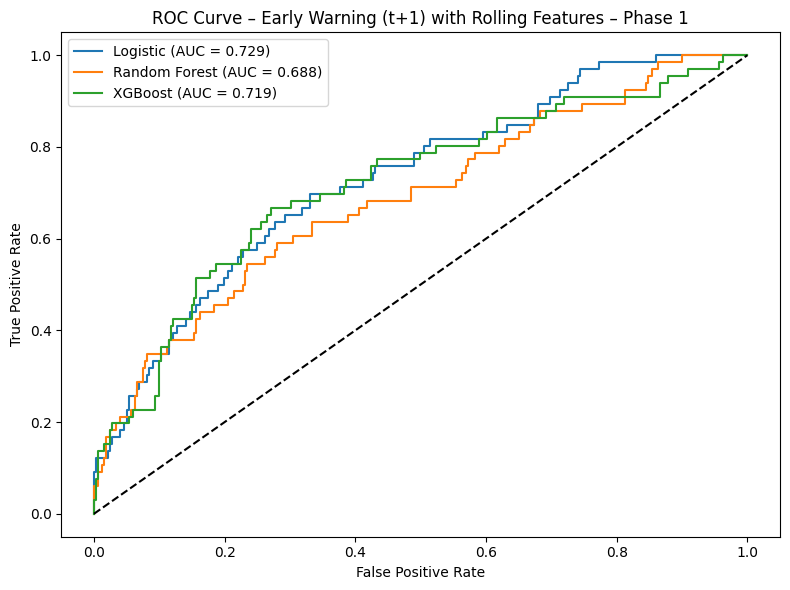


Classification Report - XGBoost (t+1):
              precision    recall  f1-score   support

         0.0       0.85      0.99      0.91       321
         1.0       0.69      0.14      0.23        66

    accuracy                           0.84       387
   macro avg       0.77      0.56      0.57       387
weighted avg       0.82      0.84      0.80       387



In [211]:
# ========== ADD ROLLING FEATURES (3-year windows) ==========
# Rolling standard deviation of exchange depreciation
master["exchange_volatility"] = (
    master.groupby("Country")["exchange_depr"]
    .rolling(3, min_periods=3)
    .std()
    .reset_index(0, drop=True)
)

# Rolling mean of GDP growth
master["gdp_rolling_mean"] = (
    master.groupby("Country")["gdp_growth"]
    .rolling(3, min_periods=3)
    .mean()
    .reset_index(0, drop=True)
)

# Drop rows where new rolling features are NaN (first 2 years per country)
master = master.dropna(subset=["exchange_volatility", "gdp_rolling_mean"])
print(f"After adding rolling features, dataset shape: {master.shape}")

# ========== CREATE T+1 TARGET ==========
master["crisis_next_year"] = master.groupby("Country")["crisis"].shift(-1)
master_early = master.dropna(subset=["crisis_next_year"])

# Train: years <= 2017 (to predict 2018 as t+1)
# Test: years > 2017
train_early = master_early[master_early["Year"] <= 2017]
test_early = master_early[master_early["Year"] > 2017]

# Define feature columns (exclude identifiers and target)
exclude_cols = ["Country", "Country Code", "Year", "crisis", "crisis_next_year"]
X_train_e = train_early.drop(columns=exclude_cols)
y_train_e = train_early["crisis_next_year"]
X_test_e = test_early.drop(columns=exclude_cols)
y_test_e = test_early["crisis_next_year"]

print(f"Training samples: {X_train_e.shape[0]}, Test samples: {X_test_e.shape[0]}")
print(f"Features: {list(X_train_e.columns)}")

# ========== SCALING FOR LOGISTIC REGRESSION ==========
from sklearn.preprocessing import StandardScaler
scaler_e = StandardScaler()
X_train_e_scaled = scaler_e.fit_transform(X_train_e)
X_test_e_scaled = scaler_e.transform(X_test_e)

# ========== LOGISTIC REGRESSION (t+1) ==========
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report

lr_params = {"C": [0.01, 0.1, 1, 10, 100], "penalty": ["l1", "l2"], "solver": ["liblinear"]}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), lr_params, cv=5, scoring="roc_auc", n_jobs=-1)
lr_grid.fit(X_train_e_scaled, y_train_e)
best_lr_e = lr_grid.best_estimator_
y_prob_lr_e = best_lr_e.predict_proba(X_test_e_scaled)[:, 1]
y_pred_lr_e = best_lr_e.predict(X_test_e_scaled)
lr_acc_e = accuracy_score(y_test_e, y_pred_lr_e)
lr_auc_e = roc_auc_score(y_test_e, y_prob_lr_e)
print(f"\nLogistic Regression (t+1) - Accuracy: {lr_acc_e:.4f}, AUC: {lr_auc_e:.4f}")
print("Best LR Params:", lr_grid.best_params_)

# ========== RANDOM FOREST (t+1) ==========
from sklearn.ensemble import RandomForestClassifier
rf_params = {
    'max_depth': [7, 10, 15],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}
rf_grid = GridSearchCV(
    RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
rf_grid.fit(X_train_e, y_train_e)   # RF does not need scaling
best_rf_e = rf_grid.best_estimator_
y_prob_rf_e = best_rf_e.predict_proba(X_test_e)[:, 1]
y_pred_rf_e = best_rf_e.predict(X_test_e)
rf_acc_e = accuracy_score(y_test_e, y_pred_rf_e)
rf_auc_e = roc_auc_score(y_test_e, y_prob_rf_e)
print(f"Random Forest (t+1) - Accuracy: {rf_acc_e:.4f}, AUC: {rf_auc_e:.4f}")
print("Best RF Params:", rf_grid.best_params_)

# Feature importance for RF
import pandas as pd
feat_imp_rf_e = pd.Series(best_rf_e.feature_importances_, index=X_train_e.columns).sort_values(ascending=False)
print("\nTop 5 RF Features (t+1):")
print(feat_imp_rf_e.head())

# ========== XGBOOST (t+1) ==========
from xgboost import XGBClassifier
xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1]
}
xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    xgb_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
xgb_grid.fit(X_train_e, y_train_e)
best_xgb_e = xgb_grid.best_estimator_
y_prob_xgb_e = best_xgb_e.predict_proba(X_test_e)[:, 1]
y_pred_xgb_e = best_xgb_e.predict(X_test_e)
xgb_acc_e = accuracy_score(y_test_e, y_pred_xgb_e)
xgb_auc_e = roc_auc_score(y_test_e, y_prob_xgb_e)
print(f"XGBoost (t+1) - Accuracy: {xgb_acc_e:.4f}, AUC: {xgb_auc_e:.4f}")
print("Best XGB Params:", xgb_grid.best_params_)

# ========== RESULTS TABLE (t+1) ==========
results_early = {
    "Logistic Regression": [lr_acc_e, lr_auc_e],
    "Random Forest": [rf_acc_e, rf_auc_e],
    "XGBoost": [xgb_acc_e, xgb_auc_e]
}
results_early_df = pd.DataFrame(results_early, index=["Accuracy", "ROC_AUC"]).T
print("\n===== PHASE 1 EARLY WARNING (t+1) WITH ROLLING FEATURES =====")
print(results_early_df)

# ========== ROC CURVES (t+1) ==========
import matplotlib.pyplot as plt
fpr_lr_e, tpr_lr_e, _ = roc_curve(y_test_e, y_prob_lr_e)
fpr_rf_e, tpr_rf_e, _ = roc_curve(y_test_e, y_prob_rf_e)
fpr_xgb_e, tpr_xgb_e, _ = roc_curve(y_test_e, y_prob_xgb_e)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr_e, tpr_lr_e, label=f"Logistic (AUC = {lr_auc_e:.3f})")
plt.plot(fpr_rf_e, tpr_rf_e, label=f"Random Forest (AUC = {rf_auc_e:.3f})")
plt.plot(fpr_xgb_e, tpr_xgb_e, label=f"XGBoost (AUC = {xgb_auc_e:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Early Warning (t+1) with Rolling Features – Phase 1")
plt.legend()
plt.tight_layout()
plt.show()

# Optional: classification report for best model (likely XGBoost)
print("\nClassification Report - XGBoost (t+1):")
print(classification_report(y_test_e, y_pred_xgb_e))

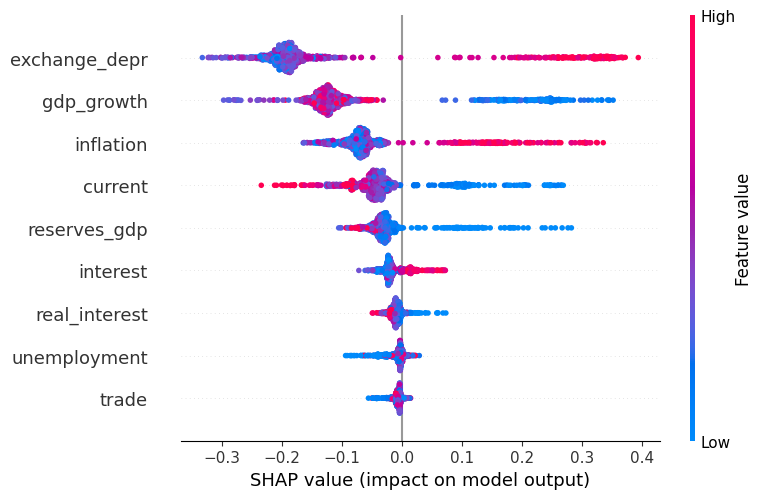

In [60]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values[:,:,1], X_train)

In [61]:
master_early["early_prob"] = rf_early.predict_proba(
    master_early[X_train_e.columns]
)[:,1]

master_early["early_fragility_index"] = master_early["early_prob"] * 100

In [62]:
def risk_level(p):
    if p < 20:
        return "Low"
    elif p < 40:
        return "Moderate"
    elif p < 60:
        return "Elevated"
    elif p < 80:
        return "High"
    else:
        return "Severe"

master_early["risk_level"] = master_early["early_fragility_index"].apply(risk_level)

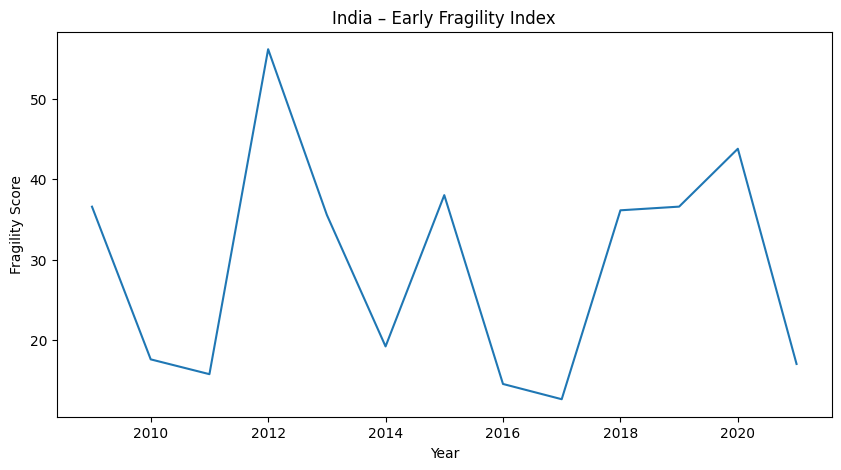

In [63]:
india = master_early[master_early["Country"] == "India"]

plt.figure(figsize=(10,5))
plt.plot(india["Year"], india["early_fragility_index"])
plt.title("India – Early Fragility Index")
plt.ylabel("Fragility Score")
plt.xlabel("Year")
plt.show()

In [64]:
master_early["actual_crisis"] = master_early["crisis_next_year"]

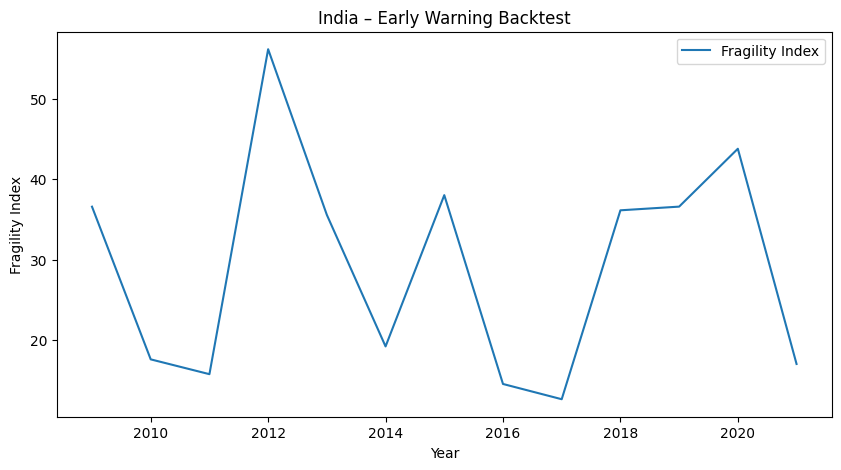

In [65]:
import matplotlib.pyplot as plt

country_name = "India"

country_df = master_early[master_early["Country"] == country_name]

plt.figure(figsize=(10,5))

plt.plot(country_df["Year"], country_df["early_fragility_index"], label="Fragility Index")

# Mark crisis years
crisis_years = country_df[country_df["actual_crisis"] == 1]["Year"]
plt.scatter(crisis_years, 
            country_df[country_df["actual_crisis"] == 1]["early_fragility_index"], 
            marker="x")

plt.title(f"{country_name} – Early Warning Backtest")
plt.xlabel("Year")
plt.ylabel("Fragility Index")
plt.legend()
plt.show()

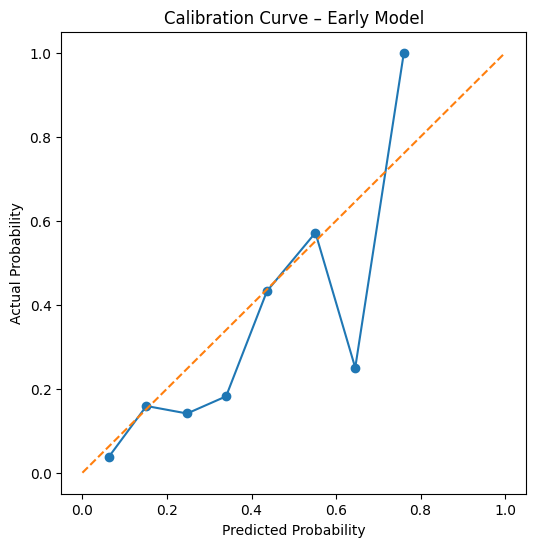

In [66]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test_e, y_prob_e, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Curve – Early Model")
plt.show()

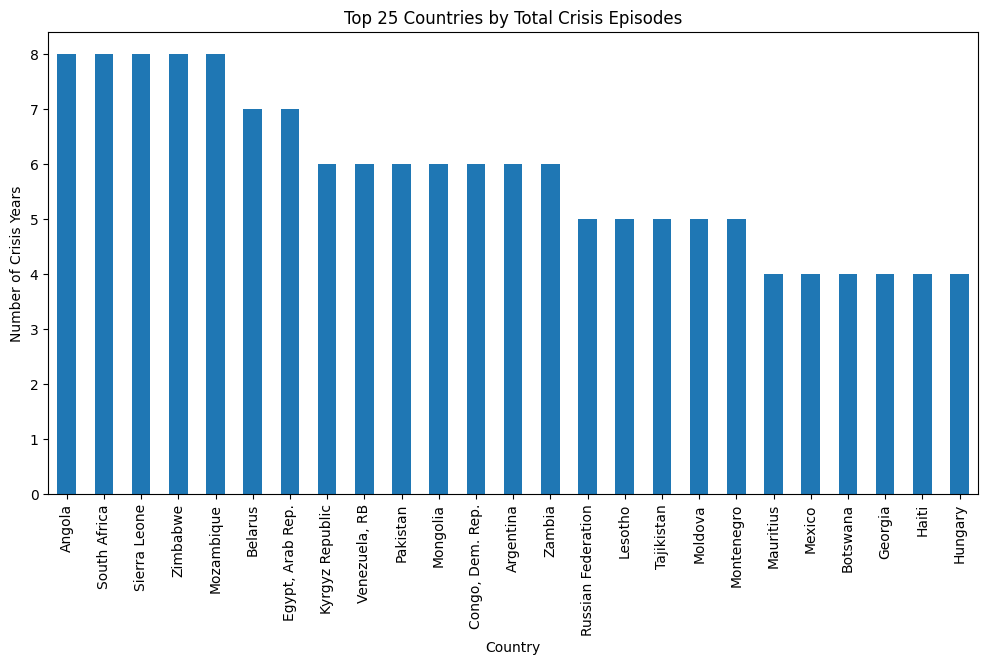

In [67]:
crisis_counts = master.groupby("Country")["crisis"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
crisis_counts.head(25).plot(kind='bar')
plt.title("Top 25 Countries by Total Crisis Episodes")
plt.ylabel("Number of Crisis Years")
plt.show()

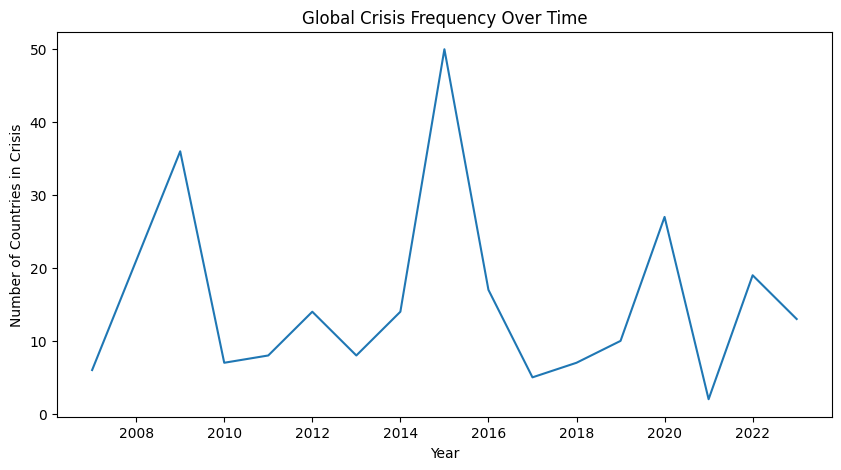

In [68]:
global_crisis_year = master.groupby("Year")["crisis"].sum()

plt.figure(figsize=(10,5))
plt.plot(global_crisis_year.index, global_crisis_year.values)
plt.title("Global Crisis Frequency Over Time")
plt.ylabel("Number of Countries in Crisis")
plt.xlabel("Year")
plt.show()

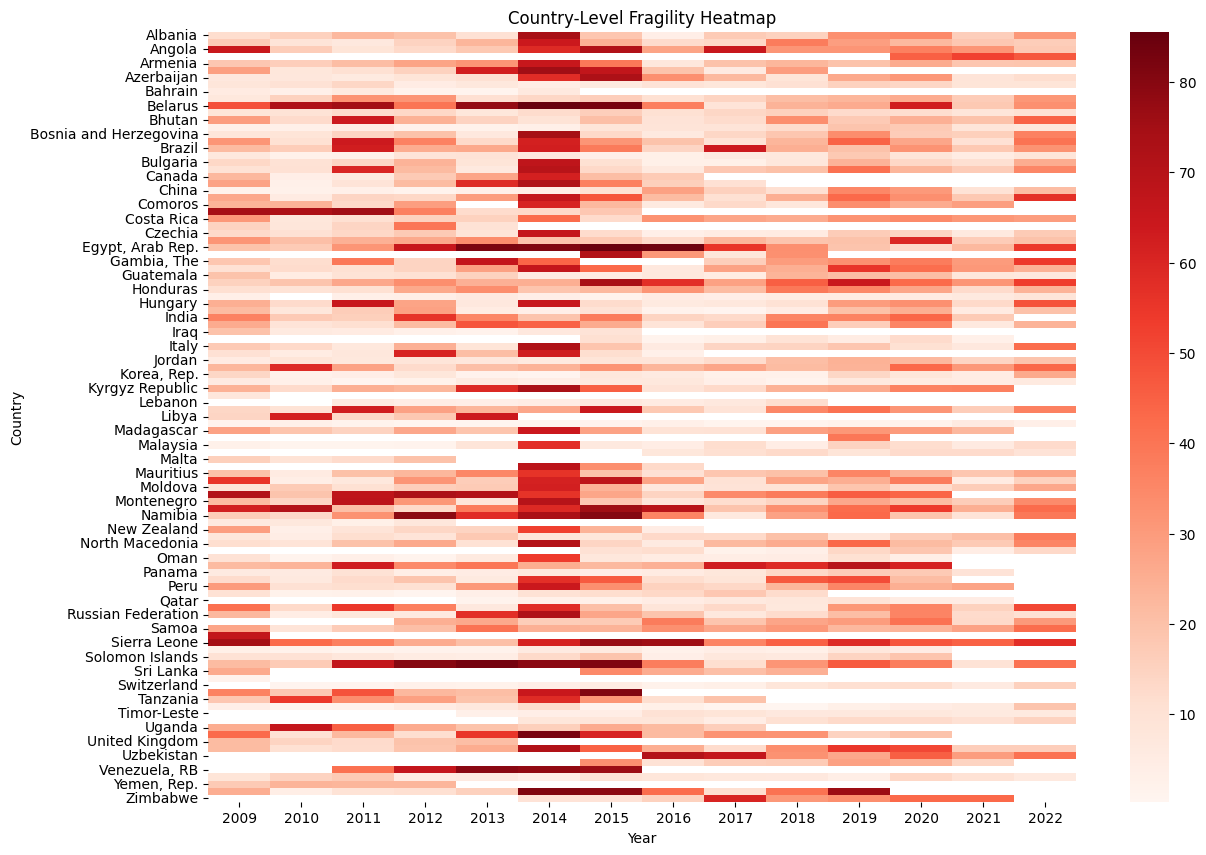

In [69]:
import seaborn as sns

pivot_fragility = master_early.pivot(
    index="Country",
    columns="Year",
    values="early_fragility_index"
)

plt.figure(figsize=(14,10))
sns.heatmap(pivot_fragility, cmap="Reds")
plt.title("Country-Level Fragility Heatmap")
plt.show()

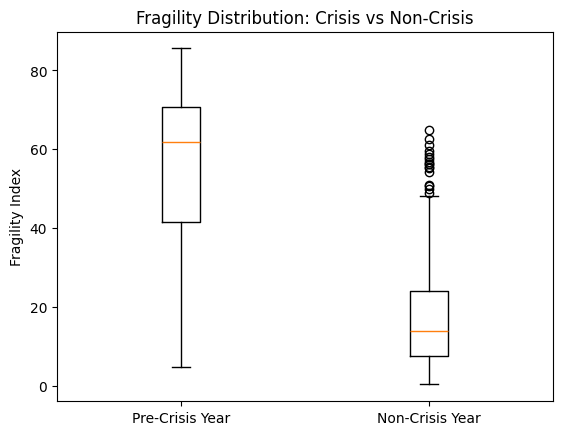

In [70]:
pre_crisis = master_early[master_early["actual_crisis"] == 1]
non_crisis = master_early[master_early["actual_crisis"] == 0]

plt.boxplot([
    pre_crisis["early_fragility_index"],
    non_crisis["early_fragility_index"]
])

plt.xticks([1,2], ["Pre-Crisis Year", "Non-Crisis Year"])
plt.title("Fragility Distribution: Crisis vs Non-Crisis")
plt.ylabel("Fragility Index")
plt.show()

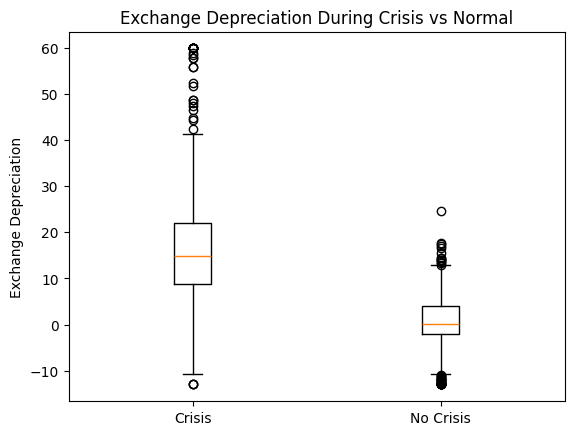

In [71]:
plt.boxplot([
    master[master["crisis"] == 1]["exchange_depr"],
    master[master["crisis"] == 0]["exchange_depr"]
])

plt.xticks([1,2], ["Crisis", "No Crisis"])
plt.title("Exchange Depreciation During Crisis vs Normal")
plt.ylabel("Exchange Depreciation")
plt.show()

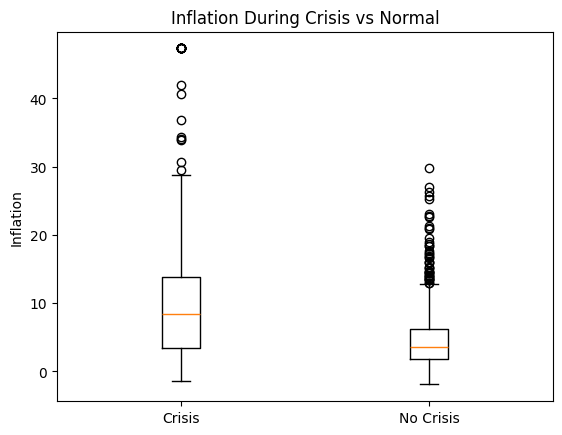

In [72]:
plt.boxplot([
    master[master["crisis"] == 1]["inflation"],
    master[master["crisis"] == 0]["inflation"]
])

plt.xticks([1,2], ["Crisis", "No Crisis"])
plt.title("Inflation During Crisis vs Normal")
plt.ylabel("Inflation")
plt.show()

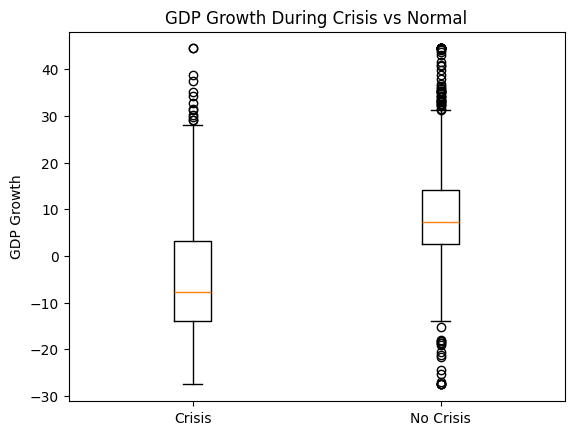

In [73]:
plt.boxplot([
    master[master["crisis"] == 1]["gdp_growth"],
    master[master["crisis"] == 0]["gdp_growth"]
])

plt.xticks([1,2], ["Crisis", "No Crisis"])
plt.title("GDP Growth During Crisis vs Normal")
plt.ylabel("GDP Growth")
plt.show()

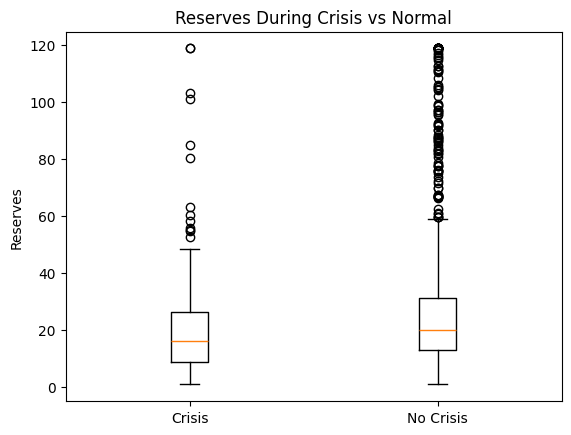

In [74]:
plt.boxplot([
    master[master["crisis"] == 1]["reserves_gdp"],
    master[master["crisis"] == 0]["reserves_gdp"]
])

plt.xticks([1,2], ["Crisis", "No Crisis"])
plt.title("Reserves During Crisis vs Normal")
plt.ylabel("Reserves")
plt.show()

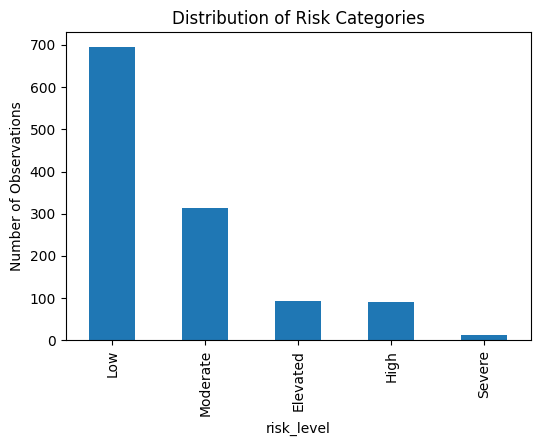

In [75]:
risk_counts = master_early["risk_level"].value_counts()

plt.figure(figsize=(6,4))
risk_counts.plot(kind='bar')
plt.title("Distribution of Risk Categories")
plt.ylabel("Number of Observations")
plt.show()

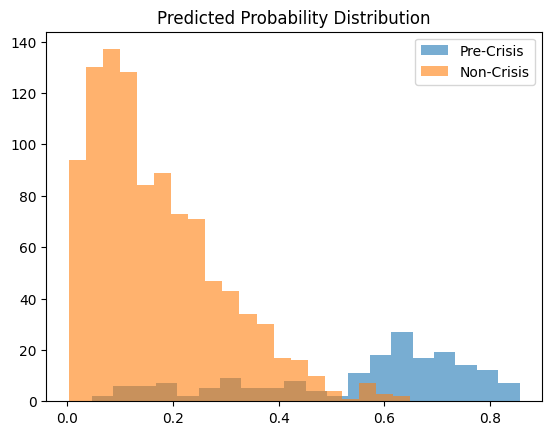

In [76]:
plt.hist(pre_crisis["early_prob"], bins=20, alpha=0.6, label="Pre-Crisis")
plt.hist(non_crisis["early_prob"], bins=20, alpha=0.6, label="Non-Crisis")

plt.legend()
plt.title("Predicted Probability Distribution")
plt.show()

In [77]:
y_prob_e = rf_early.predict_proba(X_test_e)[:,1]

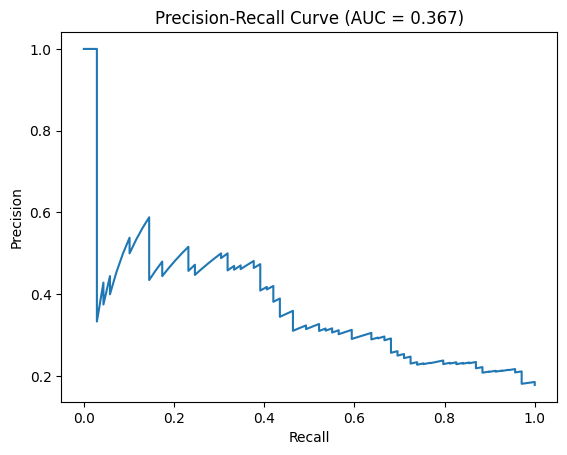

In [197]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test_e, y_prob_e)

pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {pr_auc:.3f})")
plt.show()

In [79]:
import shap

# Create SHAP explainer for Random Forest
explainer = shap.TreeExplainer(rf_early)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test_e)
shap_values_class1 = shap_values[:,:,1]

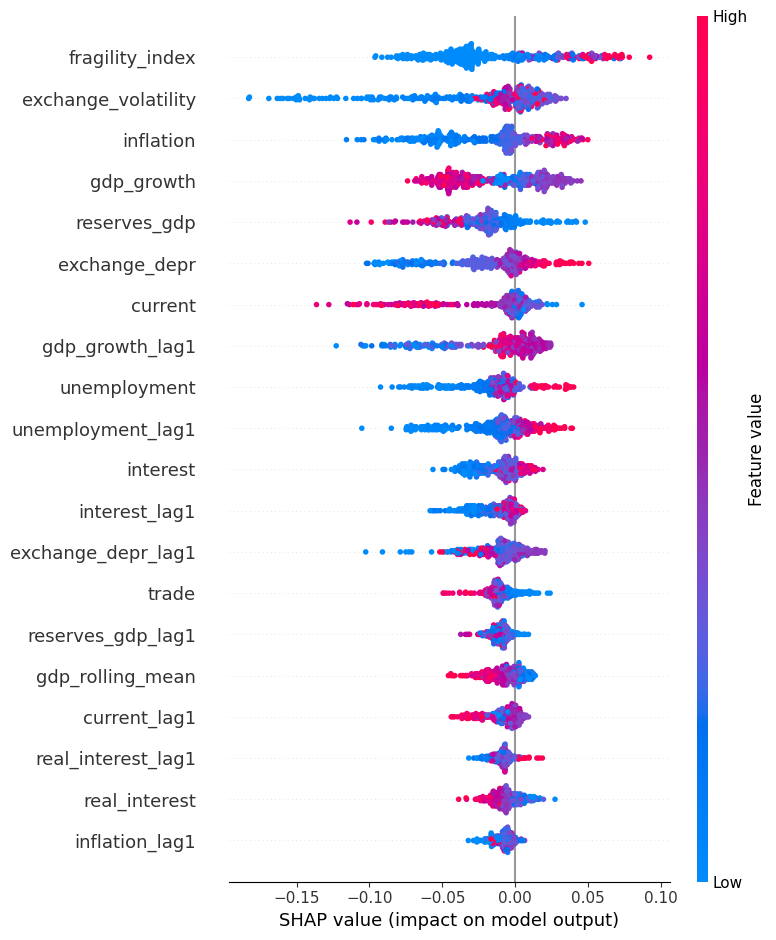

In [80]:
shap.summary_plot(shap_values_class1, X_test_e)

In [81]:
# Find one true crisis case in test set
crisis_indices = y_test_e[y_test_e == 1].index

# Select first crisis case
idx = crisis_indices[0]

print(idx)

140


In [82]:
shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1[list(X_test_e.index).index(idx)],
    X_test_e.loc[idx]
)

In [83]:
correct_crisis = X_test_e[(y_test_e == 1) & (y_pred_e == 1)].index
idx1 = correct_crisis[0]
print(idx1)

316


In [84]:
shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1[list(X_test_e.index).index(idx1)],
    X_test_e.loc[idx1]
)

In [85]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train_e, y_train_e)

# Predictions
y_pred_log = log_model.predict(X_test_e)
y_prob_log = log_model.predict_proba(X_test_e)[:,1]

# ROC
roc_log = roc_auc_score(y_test_e, y_prob_log)

# PR
precision_log, recall_log, _ = precision_recall_curve(y_test_e, y_prob_log)
pr_log = auc(recall_log, precision_log)

print("Logistic Regression")
print("ROC-AUC:", roc_log)
print("PR-AUC:", pr_log)
print(classification_report(y_test_e, y_pred_log))

Logistic Regression
ROC-AUC: 0.7191231428311001
PR-AUC: 0.4112151029855179
              precision    recall  f1-score   support

         0.0       0.90      0.71      0.79       318
         1.0       0.32      0.64      0.43        69

    accuracy                           0.70       387
   macro avg       0.61      0.67      0.61       387
weighted avg       0.80      0.70      0.73       387



In [86]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train_e[y_train_e==0]) / len(y_train_e[y_train_e==1]),
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_e, y_train_e)

y_pred_xgb = xgb_model.predict(X_test_e)
y_prob_xgb = xgb_model.predict_proba(X_test_e)[:,1]

roc_xgb = roc_auc_score(y_test_e, y_prob_xgb)

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test_e, y_prob_xgb)
pr_xgb = auc(recall_xgb, precision_xgb)

print("XGBoost")
print("ROC-AUC:", roc_xgb)
print("PR-AUC:", pr_xgb)
print(classification_report(y_test_e, y_pred_xgb))

XGBoost
ROC-AUC: 0.6912314283110017
PR-AUC: 0.36147670004695504
              precision    recall  f1-score   support

         0.0       0.86      0.91      0.88       318
         1.0       0.43      0.33      0.38        69

    accuracy                           0.80       387
   macro avg       0.65      0.62      0.63       387
weighted avg       0.79      0.80      0.79       387



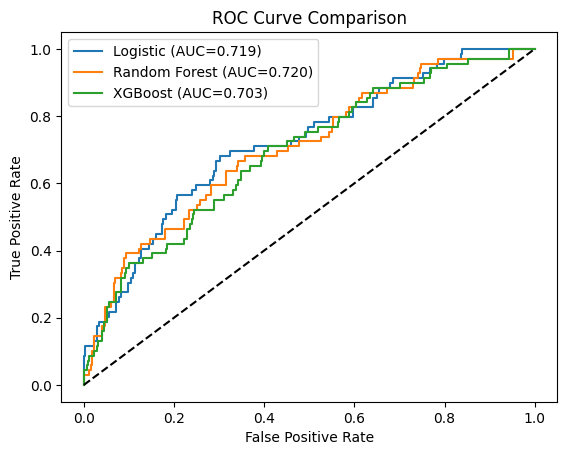

In [89]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Compute ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test_e, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test_e, y_prob_e)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_e, y_prob_xgb)

plt.figure()
plt.plot(fpr_log, tpr_log, label="Logistic (AUC=0.719)")
plt.plot(fpr_rf, tpr_rf, label="Random Forest (AUC=0.720)")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost (AUC=0.703)")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

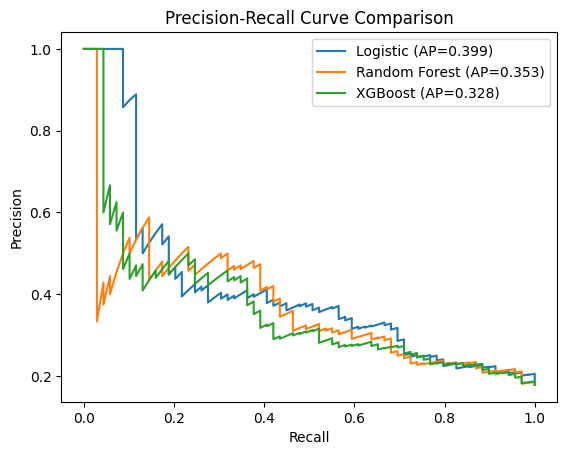

In [90]:
from sklearn.metrics import precision_recall_curve
# Compute PR curves
precision_log, recall_log, _ = precision_recall_curve(y_test_e, y_prob_log)
precision_rf, recall_rf, _ = precision_recall_curve(y_test_e, y_prob_e)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test_e, y_prob_xgb)

plt.figure()
plt.plot(recall_log, precision_log, label="Logistic (AP=0.399)")
plt.plot(recall_rf, precision_rf, label="Random Forest (AP=0.353)")
plt.plot(recall_xgb, precision_xgb, label="XGBoost (AP=0.328)")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

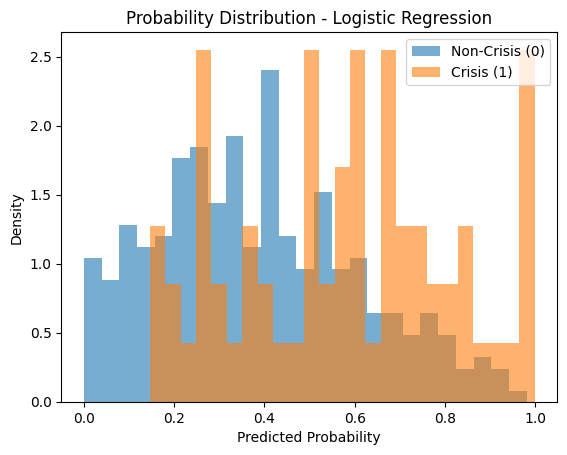

In [91]:
import matplotlib.pyplot as plt
import numpy as np

# Separate probabilities by class
probs_crisis = y_prob_log[y_test_e == 1]
probs_noncrisis = y_prob_log[y_test_e == 0]

plt.figure()

plt.hist(probs_noncrisis, bins=25, alpha=0.6, density=True, label="Non-Crisis (0)")
plt.hist(probs_crisis, bins=25, alpha=0.6, density=True, label="Crisis (1)")

plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.title("Probability Distribution - Logistic Regression")
plt.legend()
plt.show()

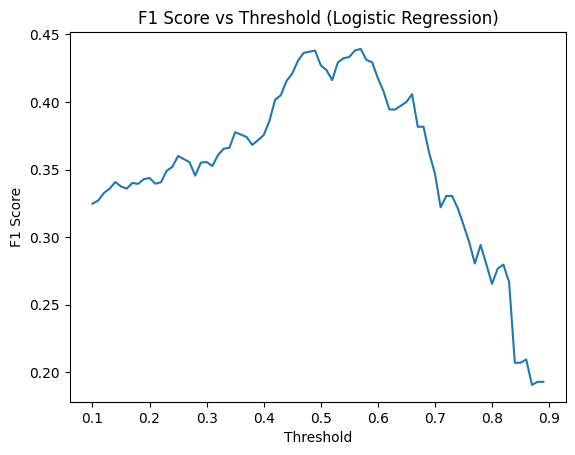

In [199]:
from sklearn.metrics import f1_score
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for t in thresholds:
    preds = (y_prob_log >= t).astype(int)
    f1_scores.append(f1_score(y_test_e, preds))

plt.figure()
plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold (Logistic Regression)")
plt.show()

optimal_threshold = thresholds[np.argmax(f1_scores)]
#print("Optimal Threshold:", optimal_threshold)

In [93]:
from sklearn.metrics import classification_report, confusion_matrix

# Default threshold (0.5)
default_preds = (y_prob_log >= 0.5).astype(int)

# Optimal threshold (0.57)
optimal_preds = (y_prob_log >= 0.57).astype(int)

print("=== Default Threshold (0.5) ===")
print(confusion_matrix(y_test_e, default_preds))
print(classification_report(y_test_e, default_preds))

print("\n=== Optimal Threshold (0.57) ===")
print(confusion_matrix(y_test_e, optimal_preds))
print(classification_report(y_test_e, optimal_preds))

=== Default Threshold (0.5) ===
[[225  93]
 [ 25  44]]
              precision    recall  f1-score   support

         0.0       0.90      0.71      0.79       318
         1.0       0.32      0.64      0.43        69

    accuracy                           0.70       387
   macro avg       0.61      0.67      0.61       387
weighted avg       0.80      0.70      0.73       387


=== Optimal Threshold (0.57) ===
[[252  66]
 [ 31  38]]
              precision    recall  f1-score   support

         0.0       0.89      0.79      0.84       318
         1.0       0.37      0.55      0.44        69

    accuracy                           0.75       387
   macro avg       0.63      0.67      0.64       387
weighted avg       0.80      0.75      0.77       387



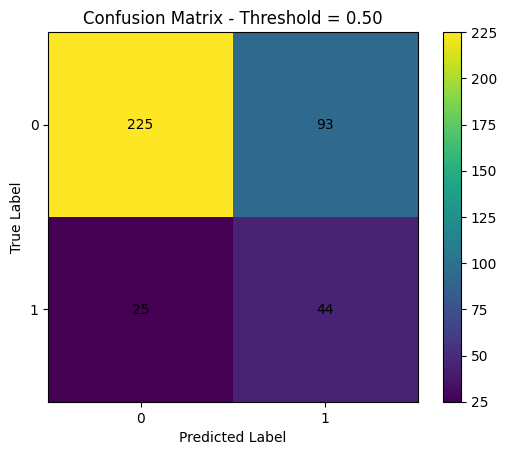

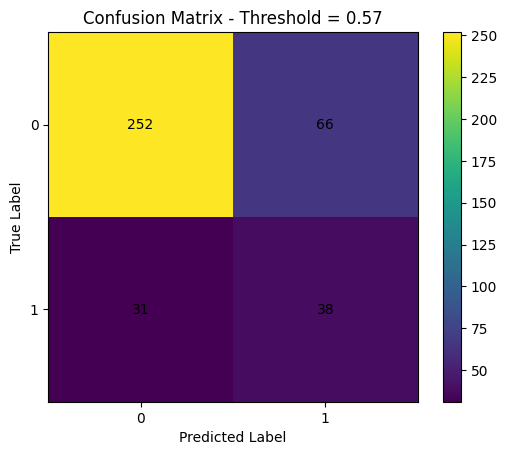

In [203]:
# Default threshold predictions
default_preds = (y_prob_log >= 0.5).astype(int)

cm_default = confusion_matrix(y_test_e, default_preds)

plt.figure()
plt.imshow(cm_default)
plt.title("Confusion Matrix - Threshold = 0.50")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm_default.shape[0]):
    for j in range(cm_default.shape[1]):
        plt.text(j, i, cm_default[i, j], ha="center", va="center")

plt.xticks([0,1])
plt.yticks([0,1])
plt.colorbar()
plt.show()


cm_optimal = confusion_matrix(y_test_e, optimal_preds)

plt.figure()
plt.imshow(cm_optimal)
plt.title("Confusion Matrix - Threshold = 0.57")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm_optimal.shape[0]):
    for j in range(cm_optimal.shape[1]):
        plt.text(j, i, cm_optimal[i, j], ha="center", va="center")

plt.xticks([0,1])
plt.yticks([0,1])
plt.colorbar()
plt.show()

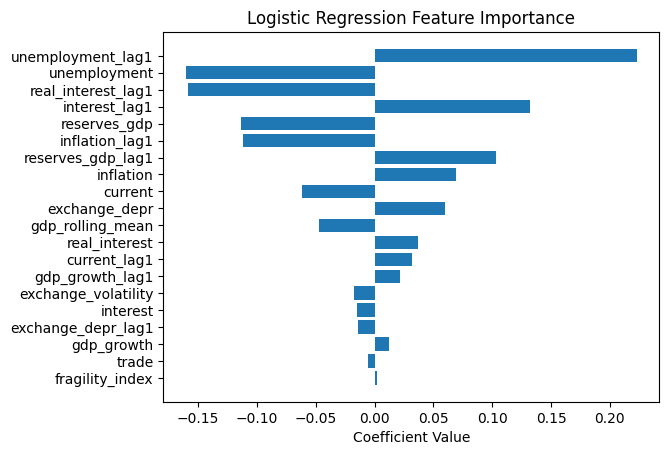

In [95]:
# Get feature names
feature_names = X_train_e.columns
# Get coefficients
coefficients = log_model.coef_[0]
# Sort by absolute importance
sorted_idx = np.argsort(np.abs(coefficients))
plt.figure()
plt.barh(feature_names[sorted_idx], coefficients[sorted_idx])
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression Feature Importance")
plt.show()

In [96]:
n_bootstraps = 1000
rng = np.random.RandomState(42)

bootstrapped_scores = []

for i in range(n_bootstraps):
    indices = rng.randint(0, len(y_test_e), len(y_test_e))
    if len(np.unique(y_test_e.iloc[indices])) < 2:
        continue

    score = roc_auc_score(y_test_e.iloc[indices], y_prob_log[indices])
    bootstrapped_scores.append(score)

sorted_scores = np.sort(bootstrapped_scores)

ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]

print("AUC 95% CI:", ci_lower, "-", ci_upper)

AUC 95% CI: 0.6516567544604928 - 0.7882905982905983


In [97]:
# 🔹 Remove leakage features and drop NaNs
features_to_drop = [
    "crisis_next_year",
    "Country",
    "Country Code",
    "Year",
    "risk_level",
    "crisis_prob",   # remove leakage
    "crisis"         # remove current crisis label
]

master_clean = master.dropna()

countries = master_clean["Country"].unique()
auc_scores = []

for country in countries:
    
    train_df = master_clean[master_clean["Country"] != country]
    test_df = master_clean[master_clean["Country"] == country]
    
    X_train = train_df.drop(columns=features_to_drop, errors="ignore")
    y_train = train_df["crisis_next_year"]
    
    X_test = test_df.drop(columns=features_to_drop, errors="ignore")
    y_test = test_df["crisis_next_year"]
    
    if len(np.unique(y_test)) < 2:
        continue
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    
    y_prob = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_prob)
    
    auc_scores.append(auc)

print("Average Country-wise AUC:", round(np.mean(auc_scores), 3))
print("Min AUC:", round(np.min(auc_scores), 3))
print("Max AUC:", round(np.max(auc_scores), 3))

Average Country-wise AUC: 0.615
Min AUC: 0.077
Max AUC: 1.0


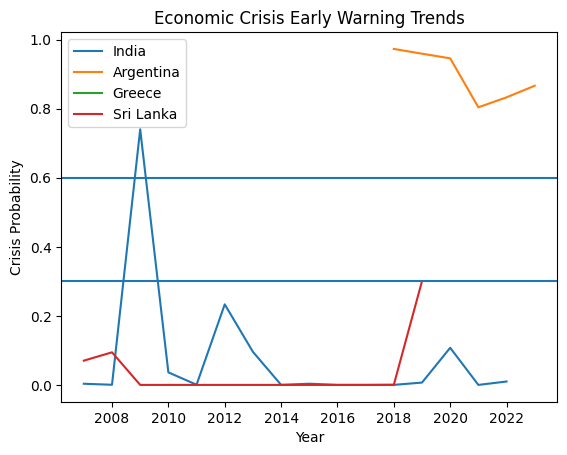

In [98]:
countries = ["India","Argentina","Greece","Sri Lanka"]

plt.figure()

for country in countries:
    temp = master[master["Country"] == country]
    plt.plot(temp["Year"], temp["crisis_prob"], label=country)

plt.axhline(0.3)
plt.axhline(0.6)

plt.title("Economic Crisis Early Warning Trends")
plt.xlabel("Year")
plt.ylabel("Crisis Probability")
plt.legend()
plt.show()

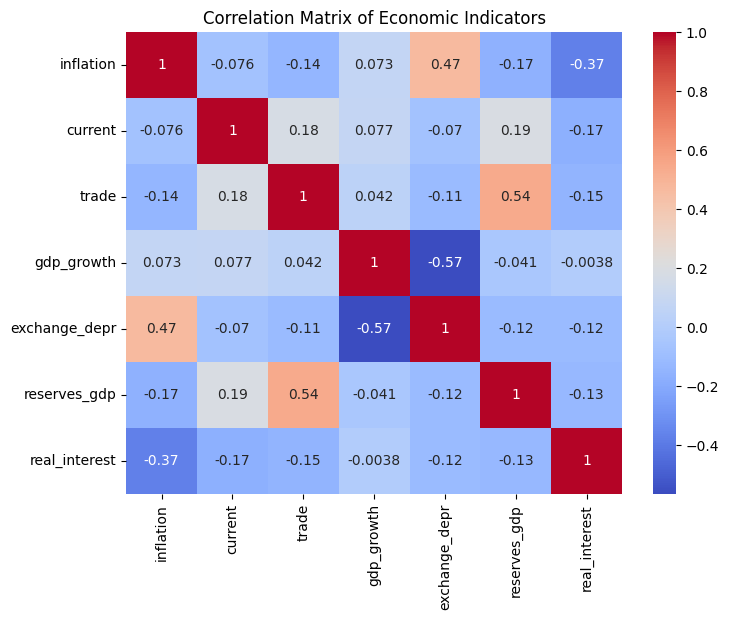

In [99]:
corr = master[[
"inflation","current","trade","gdp_growth",
"exchange_depr","reserves_gdp","real_interest"
]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Economic Indicators")
plt.show()